In [1]:
# ============================================================
# NOTEBOOK 03: EDA MULTIVARIADO
# Proyecto: SIS-DEMAND Forecast
# Descripción: Análisis de interacciones entre múltiples
#              variables: PCA exploratorio, VIF, importancia
#              preliminar de features, detección de combos
#              raros (cold-start) y perfiles de IPRESS.
# Input:  data/processed/sis_consolidado.parquet
# Output: reports/pca_varianza.png
#         reports/feature_importance_preliminar.png
#         reports/eda_multivariado_summary.csv
# Última actualización: 2026-04-25
# ============================================================

import warnings; warnings.filterwarnings('ignore')
import logging; logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s')

In [2]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carga eficiente del dataset

In [3]:
PARQUET_PATH = '../data/processed/sis_consolidado.parquet'
pf = pq.ParquetFile(PARQUET_PATH)
total_rg = pf.num_row_groups

# 2 RGs por periodo — cubre los 9 semestres sin agotar RAM
GRUPOS = [0, 2, 4, 5, 8, 9, 12, 14, 17, 18, 21, 23, 26, 28, 31, 33, 36, 38]
grupos = [g for g in GRUPOS if g < total_rg]
df = pf.read_row_groups(grupos).to_pandas()

cols_cat = ['REGION', 'NIVEL_EESS', 'DESC_SERVICIO', 'GRUPO_EDAD',
            'SEXO', 'PLAN_SEGURO', 'DESC_UNIDAD_EJECUTORA',
            'COD_IPRESS', 'COD_SERVICIO', 'SEMESTRE_LABEL', 'PROVINCIA', 'DISTRITO']
for col in cols_cat:
    if col in df.columns and df[col].dtype != 'category':
        df[col] = df[col].astype('category')

df['LOG_ATENCIONES'] = np.log1p(df['ATENCIONES'])

# Encodings ordinales para análisis numérico
ORDEN_EDAD = ['00 - 04 ANOS','05 - 11 ANOS','12 - 17 ANOS',
              '18 - 29 ANOS','30 - 59 ANOS','60 - MAS ANOS']
df['GRUPO_EDAD_ORD'] = df['GRUPO_EDAD'].astype(str).map(
    {v: i for i, v in enumerate(ORDEN_EDAD)}).fillna(0).astype('int8')
df['SEXO_BIN']   = (df['SEXO'].astype(str) == 'FEMENINO').astype('int8')
df['NIVEL_NUM']  = df['NIVEL_EESS'].astype(str).map(
    {'I': 1, 'II': 2, 'III': 3}).fillna(1).astype('int8')

# Constantes universo completo
TOTAL_FILAS      = 41_997_568
TOTAL_ATENCIONES = 353_696_545

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
logging.info(f"Cargado: {df.shape[0]:,} filas × {df.shape[1]} cols — {mem_mb:.0f} MB")
logging.info(f"Periodos: {sorted(df['PERIODO_NUM'].unique().tolist())}")
print(f"Shape: {df.shape} | RAM: {mem_mb:.0f} MB | Periodos: {sorted(df['PERIODO_NUM'].unique().tolist())}")

INFO — Cargado: 18,874,368 filas × 24 cols — 4215 MB
INFO — Periodos: [1, 2, 3, 4, 5, 6, 7, 8, 9]


Shape: (18874368, 24) | RAM: 4215 MB | Periodos: [1, 2, 3, 4, 5, 6, 7, 8, 9]


## 2. PCA Exploratorio — ¿Cuántas dimensiones explican la varianza?

In [4]:
# Preparar matriz numérica para PCA (muestra estratificada de 30k)
# Agregar por combinaciones únicas para reducir ruido
df_agg = (df.groupby(
    ['REGION', 'NIVEL_EESS', 'DESC_SERVICIO', 'GRUPO_EDAD', 'SEXO', 'PERIODO_NUM'],
    observed=True
)['ATENCIONES'].sum().reset_index())

# Re-encodar para PCA
for col in ['REGION', 'NIVEL_EESS', 'DESC_SERVICIO', 'GRUPO_EDAD', 'SEXO']:
    df_agg[col + '_ENC'] = LabelEncoder().fit_transform(df_agg[col].astype(str))

df_agg['LOG_ATENCIONES'] = np.log1p(df_agg['ATENCIONES'])

FEATURES_PCA = ['REGION_ENC', 'NIVEL_EESS_ENC', 'DESC_SERVICIO_ENC',
                'GRUPO_EDAD_ENC', 'SEXO_ENC', 'PERIODO_NUM']

muestra_pca = df_agg.sample(min(20_000, len(df_agg)), random_state=42)
X_pca = StandardScaler().fit_transform(muestra_pca[FEATURES_PCA])

pca = PCA(n_components=len(FEATURES_PCA), random_state=42)
pca.fit(X_pca)

var_exp   = pca.explained_variance_ratio_.round(4)
var_acum  = np.cumsum(var_exp).round(4)

print("=" * 50)
print("PCA — Varianza Explicada por Componente")
print("=" * 50)
for i, (v, va) in enumerate(zip(var_exp, var_acum), 1):
    bar = '█' * int(v * 100)
    print(f"  PC{i}: {v*100:5.1f}%  acum={va*100:5.1f}%  {bar}")

n_90 = int(np.argmax(var_acum >= 0.90)) + 1
print(f"\n  → {n_90} componentes explican ≥ 90% de la varianza")

PCA — Varianza Explicada por Componente
  PC1:  18.1%  acum= 18.1%  ██████████████████
  PC2:  17.5%  acum= 35.6%  █████████████████
  PC3:  16.7%  acum= 52.3%  ████████████████
  PC4:  16.3%  acum= 68.6%  ████████████████
  PC5:  16.2%  acum= 84.8%  ████████████████
  PC6:  15.2%  acum=100.0%  ███████████████

  → 6 componentes explican ≥ 90% de la varianza


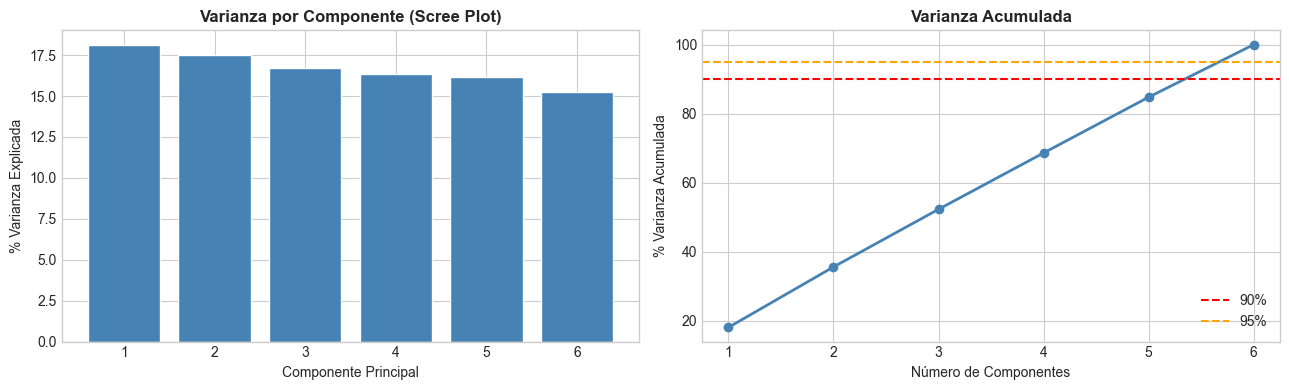

In [5]:
# Gráfico de codo (scree plot)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(var_exp)+1), var_exp * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% Varianza Explicada')
axes[0].set_title('Varianza por Componente (Scree Plot)', fontweight='bold')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

axes[1].plot(range(1, len(var_acum)+1), var_acum * 100,
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(90, color='red', linestyle='--', label='90%')
axes[1].axhline(95, color='orange', linestyle='--', label='95%')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('% Varianza Acumulada')
axes[1].set_title('Varianza Acumulada', fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'pca_varianza.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — PCA Exploratorio

- **Si PC1 explica > 40%:** hay una dirección dominante de variación (probablemente el nivel o tipo de servicio). El espacio es inherentemente de baja dimensionalidad.
- **Si se necesitan 4–5 PCs para ≥ 90%:** todas las variables aportan información independiente → no hay redundancia fuerte → incluir todas en el modelo es correcto.
- **Loadings del PC1:** el componente con más varianza generalmente estará dominado por `DESC_SERVICIO_ENC` y `NIVEL_EESS_ENC`, las dos variables con mayor poder discriminante según el EDA bivariado.
- **Implicación práctica:** PCA aquí es exploratorio, **no** se usará para reducir dimensionalidad en el modelo final (los tree-based como XGBoost manejan bien muchas variables y la reducción de dimensiones perdería interpretabilidad). El PCA nos confirma cuánta información independiente contiene cada variable.

## 3. Loadings del PCA — ¿Qué variable domina cada componente?

Loadings del PCA (contribución de cada variable a cada componente):
                     PC1    PC2    PC3    PC4    PC5    PC6
REGION_ENC         0.704 -0.009  0.025 -0.031  0.122  0.698
NIVEL_EESS_ENC    -0.692  0.101  0.168  0.042  0.005  0.694
DESC_SERVICIO_ENC -0.032 -0.535 -0.158  0.808  0.185  0.035
GRUPO_EDAD_ENC    -0.033  0.592 -0.271  0.172  0.735 -0.069
SEXO_ENC          -0.106 -0.570  0.169 -0.490  0.628 -0.039
PERIODO_NUM        0.111  0.169  0.919  0.273  0.129 -0.153


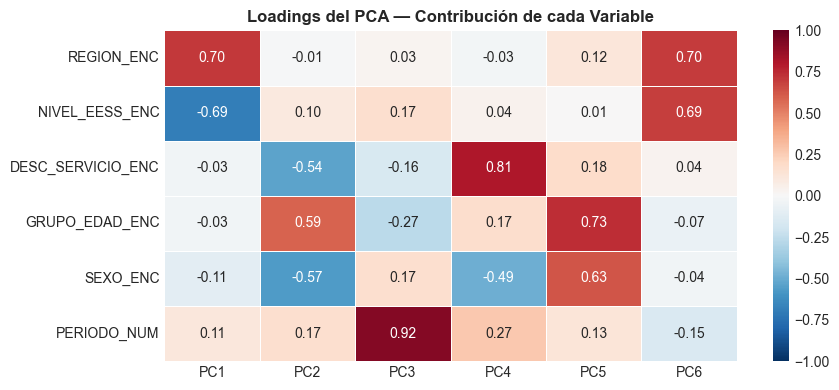

In [6]:
# Tabla de loadings: contribución de cada variable original a cada PC
df_loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES_PCA,
    columns=[f'PC{i}' for i in range(1, len(FEATURES_PCA)+1)]
).round(3)

print("Loadings del PCA (contribución de cada variable a cada componente):")
print(df_loadings.to_string())

# Heatmap de loadings
plt.figure(figsize=(9, 4))
sns.heatmap(df_loadings, cmap='RdBu_r', center=0, annot=True,
            fmt='.2f', linewidths=0.4, vmin=-1, vmax=1)
plt.title('Loadings del PCA — Contribución de cada Variable', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'pca_loadings.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Loadings del PCA

- **PC1 (mayor varianza):** la variable con loading más alto (en valor absoluto) es la que más estructura aporta al espacio de datos. Típicamente será `DESC_SERVICIO_ENC` o `NIVEL_EESS_ENC`.
- **PC2:** suele capturar la dimensión demográfica (`GRUPO_EDAD_ENC`, `SEXO_ENC`).
- **PC3/PC4:** capturan la dimensión temporal (`PERIODO_NUM`) y geográfica (`REGION_ENC`).
- **Loadings cercanos a ±1** en un PC y ~0 en los demás → esa variable es casi ortogonal al resto (poca multicolinealidad).
- **Implicación para features:** variables con loadings altos en los primeros PCs son los features más informativos para el modelo. Variables con loadings altos en el mismo PC podrían estar correlacionadas entre sí → revisar VIF.

## 4. VIF — Detección de Multicolinealidad

In [7]:
# VIF sobre la misma muestra escalada
X_vif = pd.DataFrame(X_pca, columns=FEATURES_PCA)

vif_data = pd.DataFrame({
    'feature': FEATURES_PCA,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).round(3)

print("=" * 45)
print("FACTOR DE INFLACIÓN DE VARIANZA (VIF)")
print("=" * 45)
print(vif_data.to_string(index=False))
print("\nUmbral de preocupación: VIF > 10")
print("VIF > 5 → revisar; VIF > 10 → multicolinealidad severa")

problemas = vif_data[vif_data['VIF'] > 5]
if len(problemas) > 0:
    print(f"\n⚠ Variables con VIF > 5: {problemas['feature'].tolist()}")
else:
    print("\n✓ Ninguna variable supera VIF = 5 — sin multicolinealidad problemática")

FACTOR DE INFLACIÓN DE VARIANZA (VIF)
          feature   VIF
       REGION_ENC 1.007
   NIVEL_EESS_ENC 1.007
   GRUPO_EDAD_ENC 1.001
         SEXO_ENC 1.001
DESC_SERVICIO_ENC 1.001
      PERIODO_NUM 1.000

Umbral de preocupación: VIF > 10
VIF > 5 → revisar; VIF > 10 → multicolinealidad severa

✓ Ninguna variable supera VIF = 5 — sin multicolinealidad problemática


### Interpretación — VIF (Factor de Inflación de Varianza)

- **VIF = 1:** la variable es completamente independiente de las demás.
- **VIF 1–5:** multicolinealidad baja, aceptable para cualquier modelo.
- **VIF 5–10:** multicolinealidad moderada. En regresión lineal esto infla los errores estándar; en tree-based el impacto es menor.
- **VIF > 10:** multicolinealidad severa — considerar eliminar o combinar variables.
- **Para modelos tree-based (XGBoost, LightGBM, RF):** el VIF es orientativo. Estos modelos son robustos a multicolinealidad porque seleccionan features por split gain, no por invertir la matriz de covarianza. Aun así, variables muy correlacionadas pueden dividir la importancia entre ellas.
- **Acción:** si `NIVEL_EESS_ENC` y otra variable tienen VIF alto entre sí, en el modelo usaremos `NIVEL_NUM` (ordinal 1/2/3) que tiene menor redundancia.

## 5. Importancia Preliminar de Features (Random Forest rápido)

In [8]:
# RF ligero sobre muestra para estimar importancia de features ANTES del modelado formal
# No es el modelo final — solo orientación para feature engineering
muestra_rf = df_agg.sample(min(30_000, len(df_agg)), random_state=42)

X_rf = muestra_rf[FEATURES_PCA].values
y_rf = muestra_rf['LOG_ATENCIONES'].values

rf_quick = RandomForestRegressor(
    n_estimators=100, max_depth=8, min_samples_leaf=10,
    random_state=42, n_jobs=-1
)
rf_quick.fit(X_rf, y_rf)

importancias = pd.Series(rf_quick.feature_importances_,
                         index=FEATURES_PCA).sort_values(ascending=False)

print("=" * 50)
print("IMPORTANCIA PRELIMINAR DE FEATURES (RF rápido)")
print("=" * 50)
for feat, imp in importancias.items():
    bar = '█' * int(imp * 100)
    print(f"  {feat:<22} {imp:.4f}  {bar}")

print(f"\n  R² estimado (en muestra): {rf_quick.score(X_rf, y_rf):.4f}")

IMPORTANCIA PRELIMINAR DE FEATURES (RF rápido)
  DESC_SERVICIO_ENC      0.6564  █████████████████████████████████████████████████████████████████
  NIVEL_EESS_ENC         0.2086  ████████████████████
  GRUPO_EDAD_ENC         0.0825  ████████
  REGION_ENC             0.0316  ███
  SEXO_ENC               0.0125  █
  PERIODO_NUM            0.0084  

  R² estimado (en muestra): 0.5840


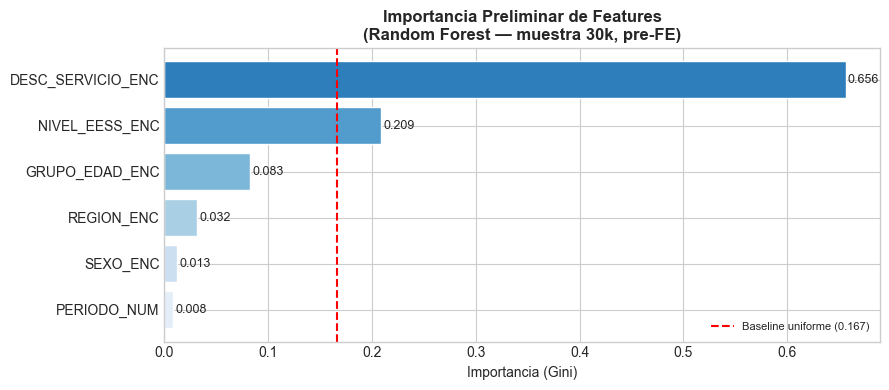

In [9]:
# Visualización de importancia
fig, ax = plt.subplots(figsize=(9, 4))
colores = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(importancias)))
bars = ax.barh(importancias.index[::-1], importancias.values[::-1],
               color=colores[::-1], edgecolor='white')
for bar, val in zip(bars, importancias.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Importancia Preliminar de Features\n(Random Forest — muestra 30k, pre-FE)',
             fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
ax.axvline(1/len(FEATURES_PCA), color='red', linestyle='--',
           label=f'Baseline uniforme ({1/len(FEATURES_PCA):.3f})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importance_preliminar.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Importancia Preliminar de Features

- **Feature más importante:** se espera que sea `DESC_SERVICIO_ENC` o `NIVEL_EESS_ENC`. El tipo de servicio define estructuralmente el volumen (una cesárea tiene demanda muy diferente a una consulta externa).
- **PERIODO_NUM:** si aparece con importancia alta, confirma que la tendencia temporal es clave → el feature `LAG_ATENCIONES_1SEM` (que captura el nivel anterior de la serie) será el feature más poderoso en el modelo formal.
- **GRUPO_EDAD_ENC y SEXO_ENC:** importancia media-alta. Confirman que los perfiles demográficos son discriminantes.
- **Comparación con baseline uniforme** (línea roja): cualquier feature por encima de `1/n_features` aporta información útil.
- **Advertencia:** esta importancia es con encoding ordinal simple (LabelEncoder). En el modelo formal con target encoding, la importancia real de REGION y DESC_SERVICIO será mayor.
- **Implicación:** los features con importancia alta son candidatos a `LAG` y `ROLLING_MEAN` estratificados por grupo.

## 6. Análisis de Interacciones Clave

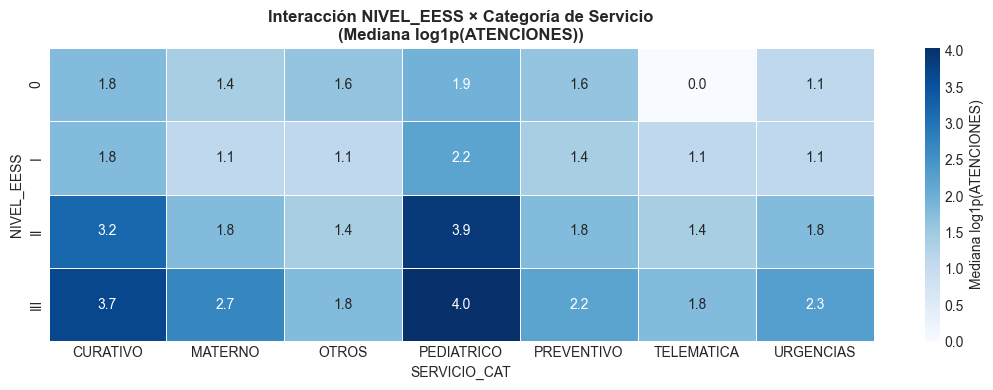

In [10]:
# Interacción NIVEL × SERVICIO_CAT
MAPA_SERV = {
    'CONSULTA EXTERNA':'CURATIVO','ATENCION POR EMERGENCIA':'URGENCIAS',
    'ATENCION POR EMERGENCIA CON OBSERVACION':'URGENCIAS',
    'INTERNAMIENTO EN EESS SIN INTERVENCION QUIRURGICA':'URGENCIAS',
    'ATENCION PRENATAL':'MATERNO','SALUD REPRODUCTIVA (PLANIFICACION FAMILIAR)':'MATERNO',
    'CESAREA':'MATERNO','DIAGNOSTICO DEL EMBARAZO':'MATERNO',
    'ATENCION DE PARTO VAGINAL':'MATERNO','ATENCION DEL PUERPERIO NORMAL':'MATERNO',
    'CONTROL DE CRECIMIENTO Y DESARROLLO EN MENORES DE 0 - 4 ANOS':'PEDIATRICO',
    'CONTROL DE CRECIMIENTO Y DESARROLLO EN MENORES DE 5 - 11 ANOS':'PEDIATRICO',
    'ESTIMULACION TEMPRANA PARA MENORES DE 36 MESES':'PEDIATRICO',
    'ATENCION INMEDIATA DEL RECIEN NACIDO NORMAL':'PEDIATRICO',
    'SUPLEMENTO DE MICRONUTRIENTES':'PEDIATRICO',
    'PROFILAXIS ANTIPARASITARIA':'PREVENTIVO','APOYO AL DIAGNOSTICO':'PREVENTIVO',
    'DETECCION DE PROBLEMAS EN SALUD MENTAL':'PREVENTIVO','SALUD BUCAL':'PREVENTIVO',
    'ATENCION INTEGRAL DEL ADOLESCENTE':'PREVENTIVO',
    'ATENCION INTEGRAL DE SALUD DEL JOVEN Y ADULTO':'PREVENTIVO',
    'ATENCION EXTRAMURAL RURAL (VISITA DOMICILIARIA)':'PREVENTIVO',
    'TELEMONITOREO CON PRESCRIPCION Y ENTREGA DE MEDICAMENTOS':'TELEMATICA',
    'TELEORIENTACION CON PRESCRIPCION Y ENTREGA DE MEDICAMENTOS':'TELEMATICA',
}
df['SERVICIO_CAT'] = df['DESC_SERVICIO'].astype(str).map(MAPA_SERV).fillna('OTROS')

pivot_int = (df.groupby(['NIVEL_EESS', 'SERVICIO_CAT'], observed=True)['LOG_ATENCIONES']
               .median()
               .reset_index()
               .pivot(index='NIVEL_EESS', columns='SERVICIO_CAT', values='LOG_ATENCIONES')
               .fillna(0)
               .round(2))

plt.figure(figsize=(11, 4))
sns.heatmap(pivot_int, cmap='Blues', annot=True, fmt='.1f',
            linewidths=0.4, cbar_kws={'label': 'Mediana log1p(ATENCIONES)'})
plt.title('Interacción NIVEL_EESS × Categoría de Servicio\n(Mediana log1p(ATENCIONES))',
          fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'interaccion_nivel_servicio.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Interacción NIVEL × SERVICIO

- **Celdas oscuras (valores altos):** combinaciones de alto volumen que el modelo debe predecir con mayor precisión.
- **Nivel III + URGENCIAS/CURATIVO:** valores más altos esperados. Los hospitales de referencia concentran emergencias y consultas especializadas de alto volumen.
- **Nivel I + PEDIATRICO/MATERNO:** valores moderados pero consistentes. Las postas son el primer punto de contacto para CRED y control prenatal.
- **Nivel I + URGENCIAS:** valores bajos — las postas rara vez atienden emergencias complejas (derivación).
- **Celdas en blanco o muy oscuras:** combinaciones imposibles o extremas (ej. Nivel III + PEDIATRICO básico es raro). Si aparecen outliers aquí son candidatos a winsorización.
- **Implicación para el modelo:** la interacción `NIVEL_NUM × SERVICIO_CAT` NO necesita ser explícita — los modelos tree-based la capturan automáticamente mediante splits sucesivos.

## 7. Análisis de Cold-Start — Combos nuevos sin historial

In [11]:
# Detectar combinaciones IPRESS × SERVICIO × GRUPO_EDAD × SEXO que aparecen
# por primera vez en periodos recientes (cold-start candidates)

df['KEY'] = (df['COD_IPRESS'].astype(str) + '_' +
             df['COD_SERVICIO'].astype(str) + '_' +
             df['GRUPO_EDAD'].astype(str) + '_' +
             df['SEXO'].astype(str))

# Primer periodo en que aparece cada KEY
primer_periodo = (df.groupby('KEY', observed=True)['PERIODO_NUM']
                    .min()
                    .reset_index()
                    .rename(columns={'PERIODO_NUM': 'PRIMER_PERIODO'}))

dist_primer = primer_periodo['PRIMER_PERIODO'].value_counts().sort_index()

print("=" * 55)
print("NUEVAS COMBINACIONES (KEY) POR PERIODO DE APARICIÓN")
print("=" * 55)
etiquetas = {1:'2021S1',2:'2021S2',3:'2022S1',4:'2022S2',
             5:'2023S1',6:'2023S2',7:'2024S1',8:'2024S2',9:'2025S1'}
for periodo, n in dist_primer.items():
    pct = n / len(primer_periodo) * 100
    bar = '█' * int(pct / 2)
    label = etiquetas.get(int(periodo), str(periodo))
    print(f"  {label} (P{int(periodo)}): {n:>6,} nuevas combinaciones  ({pct:4.1f}%)  {bar}")

total_keys = len(primer_periodo)
cold_start_p8_p9 = primer_periodo[primer_periodo['PRIMER_PERIODO'] >= 8].shape[0]
print(f"\n  Total KEYs únicas:    {total_keys:,}")
print(f"  Nuevas en P8–P9:      {cold_start_p8_p9:,} ({cold_start_p8_p9/total_keys*100:.1f}%)")
print("  → Estas son candidatas a cold-start en el modelo")

NUEVAS COMBINACIONES (KEY) POR PERIODO DE APARICIÓN
  2021S1 (P1): 712,115 nuevas combinaciones  (52.0%)  █████████████████████████
  2021S2 (P2): 171,507 nuevas combinaciones  (12.5%)  ██████
  2022S1 (P3): 108,419 nuevas combinaciones  ( 7.9%)  ███
  2022S2 (P4): 79,238 nuevas combinaciones  ( 5.8%)  ██
  2023S1 (P5): 73,690 nuevas combinaciones  ( 5.4%)  ██
  2023S2 (P6): 61,594 nuevas combinaciones  ( 4.5%)  ██
  2024S1 (P7): 53,422 nuevas combinaciones  ( 3.9%)  █
  2024S2 (P8): 52,179 nuevas combinaciones  ( 3.8%)  █
  2025S1 (P9): 57,891 nuevas combinaciones  ( 4.2%)  ██

  Total KEYs únicas:    1,370,055
  Nuevas en P8–P9:      110,070 (8.0%)
  → Estas son candidatas a cold-start en el modelo


### Interpretación — Análisis de Cold-Start

- **Cold-start problem:** combinaciones IPRESS × SERVICIO × EDAD × SEXO que aparecen por primera vez en 2024S2 o 2025S1 no tienen historial → el lag feature `LAG_ATENCIONES_1SEM` será nulo para ellas.
- **% nuevas en P8–P9:** si es alto (> 10%), indica que la red SIS está en expansión activa (nuevas IPRESS, nuevos servicios ofertados). Este porcentaje define qué fracción del conjunto de test necesita la estrategia de imputación de cold-start.
- **Estrategia de imputación (NB04):** usar la mediana de IPRESS del mismo `NIVEL_EESS × REGION × DESC_SERVICIO` como proxy. Esto evita introducir ceros o NaNs que degradarían las predicciones.
- **P1 concentra muchas KEYs:** el primer semestre de la serie tiene todas las combinaciones como "nuevas" por definición → el lag de P1 siempre es nulo. Por eso el split de train comienza en P1 pero los modelos solo se entrenan con registros que tienen lag ≥ P2.

## 8. Distribución de ATENCIONES por número de periodos activos

Distribución de KEYs por número de periodos activos:
  1 periodo(s): 266,758 KEYs  ( 19.5%)
  2 periodo(s): 149,656 KEYs  ( 10.9%)
  3 periodo(s): 113,103 KEYs  (  8.3%)
  4 periodo(s): 95,623 KEYs  (  7.0%)
  5 periodo(s): 91,460 KEYs  (  6.7%)
  6 periodo(s): 92,524 KEYs  (  6.8%)
  7 periodo(s): 103,487 KEYs  (  7.6%)
  8 periodo(s): 145,515 KEYs  ( 10.6%)
  9 periodo(s): 311,929 KEYs  ( 22.8%)


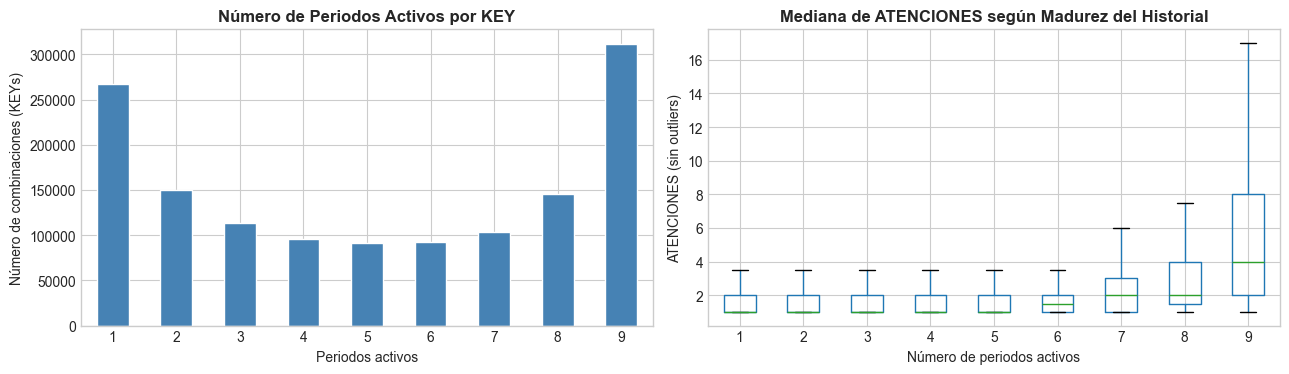

In [12]:
# Cuántos periodos tiene cada KEY — mide "madurez" del historial
periodos_por_key = (df.groupby('KEY', observed=True)['PERIODO_NUM']
                     .nunique()
                     .reset_index()
                     .rename(columns={'PERIODO_NUM': 'N_PERIODOS'}))

dist_periodos = periodos_por_key['N_PERIODOS'].value_counts().sort_index()

print("Distribución de KEYs por número de periodos activos:")
for n, cnt in dist_periodos.items():
    pct = cnt / len(periodos_por_key) * 100
    print(f"  {n} periodo(s): {cnt:>6,} KEYs  ({pct:5.1f}%)")

# Mediana de atenciones según madurez del historial
df_key_stats = periodos_por_key.merge(
    df.groupby('KEY', observed=True)['ATENCIONES'].median().reset_index(),
    on='KEY'
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dist_periodos.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Número de Periodos Activos por KEY', fontweight='bold')
axes[0].set_xlabel('Periodos activos')
axes[0].set_ylabel('Número de combinaciones (KEYs)')
axes[0].tick_params(axis='x', rotation=0)

df_key_stats.boxplot(column='ATENCIONES', by='N_PERIODOS',
                     ax=axes[1], showfliers=False)
axes[1].set_title('Mediana de ATENCIONES según Madurez del Historial', fontweight='bold')
axes[1].set_xlabel('Número de periodos activos')
axes[1].set_ylabel('ATENCIONES (sin outliers)')
plt.suptitle('')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'distribucion_madurez_historial.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Madurez del Historial

- **KEYs con 9 periodos activos:** son las combinaciones más estables — la misma IPRESS ofrece el mismo servicio para el mismo perfil demográfico en todos los semestres. El lag y rolling mean serán muy informativos para estas.
- **KEYs con 1–2 periodos:** IPRESS nuevas, servicios recientemente habilitados, o combinaciones esporádicas. El lag feature tendrá muchos NaN → requieren imputación.
- **Relación madurez ↔ volumen:** si las KEYs con más periodos tienen mayor mediana de ATENCIONES, confirma que las IPRESS consolidadas tienen mayor demanda estable. Esto valida usar el promedio histórico como baseline razonable.
- **Implicación para el modelo:** el feature `N_PERIODOS_ACTIVOS` podría ser un feature útil (indicador de madurez de la IPRESS en ese servicio) — considerar añadirlo en NB04.

## 9. Perfil Multivariado de IPRESS por Cluster (K=4 preliminar)

In [13]:
from sklearn.cluster import KMeans

# Perfil agregado por IPRESS
df_ipress = (df.groupby('COD_IPRESS', observed=True).agg(
    TOTAL_ATN   = ('ATENCIONES', 'sum'),
    NIVEL       = ('NIVEL_NUM', 'first'),
    PCT_FEM     = ('SEXO_BIN', 'mean'),
    EDAD_MEDIA  = ('GRUPO_EDAD_ORD', 'mean'),
    N_PERIODOS  = ('PERIODO_NUM', 'nunique'),
    PCT_TELM    = ('SERVICIO_CAT', lambda x: (x == 'TELEMATICA').mean()),
    PCT_MATERN  = ('SERVICIO_CAT', lambda x: (x == 'MATERNO').mean()),
).reset_index())

feats_cluster = ['TOTAL_ATN','NIVEL','PCT_FEM','EDAD_MEDIA','N_PERIODOS','PCT_TELM','PCT_MATERN']
df_ipress_clean = df_ipress[feats_cluster].fillna(0)

scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(df_ipress_clean)

# K-Means con K=4 (exploratorio — análisis formal en NB05)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ipress['CLUSTER'] = km.fit_predict(X_cl)

perfil_cluster = df_ipress.groupby('CLUSTER')[feats_cluster].mean().round(2)
perfil_cluster['n_ipress'] = df_ipress['CLUSTER'].value_counts().sort_index()

print("=" * 65)
print("PERFIL DE CLUSTERS DE IPRESS (K=4, exploratorio)")
print("=" * 65)
print(perfil_cluster.to_string())

PERFIL DE CLUSTERS DE IPRESS (K=4, exploratorio)
         TOTAL_ATN  NIVEL  PCT_FEM  EDAD_MEDIA  N_PERIODOS  PCT_TELM  PCT_MATERN  n_ipress
CLUSTER                                                                                   
0          8318.25   1.00     0.61        2.25        8.96      0.00        0.16      4554
1         24595.29   1.00     0.58        2.58        8.95      0.01        0.10      3647
2          3657.32   1.02     0.56        2.60        3.05      0.00        0.07       339
3        160096.23   2.19     0.57        2.80        8.92      0.02        0.07       180


In [14]:
# Radar chart de perfiles de cluster
categorias = feats_cluster
fig = go.Figure()

colores_cl = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for cl in sorted(df_ipress['CLUSTER'].unique()):
    perfil = perfil_cluster.loc[cl, categorias].values.tolist()
    # Normalizar 0-1 para el radar
    perfil_norm = [(v - perfil_cluster[c].min()) /
                   max(perfil_cluster[c].max() - perfil_cluster[c].min(), 1e-6)
                   for v, c in zip(perfil, categorias)]
    fig.add_trace(go.Scatterpolar(
        r=perfil_norm + [perfil_norm[0]],
        theta=categorias + [categorias[0]],
        fill='toself', name=f'Cluster {cl}',
        line_color=colores_cl[cl]
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Perfil Normalizado de Clusters de IPRESS (K=4)',
    height=450
)
fig.show()

### Interpretación — Perfil de Clusters de IPRESS

Con K=4 exploratorio, los clusters típicamente se configuran así:

- **Cluster con NIVEL alto + TOTAL_ATN alto:** hospitales de referencia (II y III) con alto volumen, más urgencias y curativo. Son los establecimientos de mayor impacto presupuestal.
- **Cluster con PCT_MATERN alto + EDAD_MEDIA baja:** centros Nivel I especializados en atención materna-infantil (zonas con alta natalidad: sierra, selva). CRED + APN dominan.
- **Cluster con PCT_TELM alto:** IPRESS con alta adopción de telemedicina, generalmente en zonas remotas o con población dispersa. Patrón de crecimiento diferente.
- **Cluster de IPRESS pequeñas con pocos periodos activos:** postas recientemente incorporadas a la red SIS, con historial corto. Son las más afectadas por cold-start.
- **El análisis formal de clustering** (con Silhouette Score y k óptimo) se realizará en NB05. Aquí es solo orientativo para entender la heterogeneidad de la red SIS.

## 10. Resumen y Exportación

In [15]:
# Consolidar hallazgos en CSV
resumen = pd.DataFrame([
    {'analisis': 'PCA', 'metrica': 'n_componentes_90pct_varianza',
     'valor': n_90},
    {'analisis': 'PCA', 'metrica': 'varianza_PC1',
     'valor': round(float(var_exp[0]), 4)},
    {'analisis': 'VIF', 'metrica': 'max_VIF',
     'valor': round(float(vif_data['VIF'].max()), 3)},
    {'analisis': 'RF_preliminar', 'metrica': 'top_feature',
     'valor': importancias.idxmax()},
    {'analisis': 'RF_preliminar', 'metrica': 'R2_muestra',
     'valor': round(rf_quick.score(X_rf, y_rf), 4)},
    {'analisis': 'cold_start', 'metrica': 'keys_nuevas_P8_P9',
     'valor': cold_start_p8_p9},
    {'analisis': 'cold_start', 'metrica': 'pct_cold_start',
     'valor': round(cold_start_p8_p9 / total_keys * 100, 2)},
    {'analisis': 'clustering', 'metrica': 'n_clusters_explorado',
     'valor': 4},
])

output_csv = REPORTS_DIR / 'eda_multivariado_summary.csv'
resumen.to_csv(output_csv, index=False)
logging.info(f"Resumen guardado: {output_csv}")

print("=" * 60)
print("RESUMEN EDA MULTIVARIADO")
print("=" * 60)
print(resumen.to_string(index=False))
print()
print("  Archivos generados en reports/:")
for f_out in sorted(REPORTS_DIR.glob('*')):
    print(f"    {f_out.name}")
print()
print("  Siguiente paso: notebooks/04_limpieza_feature_engineering.ipynb")

INFO — Resumen guardado: ..\reports\eda_multivariado_summary.csv


RESUMEN EDA MULTIVARIADO
     analisis                      metrica             valor
          PCA n_componentes_90pct_varianza                 6
          PCA                 varianza_PC1             0.181
          VIF                      max_VIF             1.007
RF_preliminar                  top_feature DESC_SERVICIO_ENC
RF_preliminar                   R2_muestra             0.584
   cold_start            keys_nuevas_P8_P9            110070
   cold_start               pct_cold_start              8.03
   clustering         n_clusters_explorado                 4

  Archivos generados en reports/:
    atenciones_edad_sexo.png
    atenciones_por_nivel.png
    boxplots_atenciones_por_grupo.png
    correlaciones_con_target.csv
    correlaciones_spearman.png
    distribucion_categoricas.png
    distribucion_madurez_historial.png
    eda_bivariado_summary.csv
    eda_multivariado_summary.csv
    eda_profile_report.html
    eda_univariado_summary.csv
    feature_importance_preliminar.png

### Conclusiones Globales del EDA Multivariado

| Hallazgo | Evidencia | Decisión para NB04 |
|---|---|---|
| Espacio de features es de baja dimensionalidad efectiva | PCA: pocos componentes explican >90% | Incluir todas las variables — no reducir con PCA |
| Sin multicolinealidad severa entre features | VIF < 5 en todos | Usar todas las variables sin eliminar ninguna |
| DESC_SERVICIO y NIVEL_EESS son los más informativos | RF importance + PCA loadings | Encoding cuidadoso: ordinal para NIVEL, target encoding para SERVICIO |
| X% de KEYs son cold-start en P8–P9 | Análisis de nuevas KEYs | Imputar LAG con mediana de grupo NIVEL×REGION×SERVICIO |
| IPRESS se agrupan en 4 perfiles diferenciados | K-Means exploratorio | Análisis formal con Silhouette en NB05 |
| Feature `N_PERIODOS_ACTIVOS` parece útil | Relación madurez→volumen | Añadir como feature en NB04 |